### Thermo Sudoku LP Solver
Base code is adapted from https://github.com/Lakshmi-1212/Sudoku_Solver_LP.git

In [1]:
import pulp as plp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
def add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values):
    
    # Constraint to ensure only one value is filled for a cell
    for row in rows:
        for col in cols:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value] for value in values]),
                                        sense=plp.LpConstraintEQ, rhs=1, name=f"constraint_sum_{row}_{col}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in a row        
    for row in rows:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for col in cols]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_row_{row}_{value}"))

    # Constraint to ensure that values from 1 to 9 is filled only once in a column        
    for col in cols:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for row in rows]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_col_{col}_{value}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in the 3x3 grid       
    for grid in grids:
        grid_row  = int(grid/3)
        grid_col  = int(grid%3)

        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[grid_row*3+row][grid_col*3+col][value]*value  for col in range(0,3) for row in range(0,3)]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_grid_{grid}_{value}"))

In [3]:
def add_diagonal_sudoku_constraints(prob, grid_vars, rows, cols, values):
    
        # Constraint from top-left to bottom-right - numbers 1 - 9 should not repeat
        for value in values:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][row][value]*value  for row in rows]),
                                            sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_diag1_{value}"))


        # Constraint from top-right to bottom-left - numbers 1 - 9 should not repeat
        for value in values:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][len(rows)-row-1][value]*value  for row in rows]),
                                            sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_diag2_{value}"))


In [4]:
def add_thermo_sudoku_constraints(prob, grid_vars, values, thermometer_list):
    t_idx = 0
    for t in thermometer_list:
        for pos in range(len(t) - 1):
            prev_row, prev_col = t[pos][0] - 1, t[pos][1] - 1
            next_row, next_col = t[pos + 1][0] - 1, t[pos + 1][1] - 1

            prev_val = plp.lpSum([grid_vars[prev_row][prev_col][v] * v for v in values])
            next_val = plp.lpSum([grid_vars[next_row][next_col][v] * v for v in values])

            prob.addConstraint(plp.LpConstraint(e=next_val - prev_val, 
                                                sense=plp.LpConstraintGE,
                                                rhs=1,
                                                name=f"Thermo_{t_idx}_{pos}"))
        t_idx += 1

In [5]:
def add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values):
    for row in rows:
        for col in cols:
            if(input_sudoku[row][col] != 0):
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for value in values]), 
                                                    sense=plp.LpConstraintEQ, 
                                                    rhs=input_sudoku[row][col],
                                                    name=f"constraint_prefilled_{row}_{col}"))

In [6]:
# Extract solution from the target variable to a list array

def extract_solution(grid_vars, rows, cols, values):
    solution = [[0 for col in cols] for row in rows]
    grid_list = []
    for row in rows:
        for col in cols:
            for value in values:
                if plp.value(grid_vars[row][col][value]):
                    solution[row][col] = value 
    return solution

In [7]:

THERMO_COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
                 '#edc948','#b07aa1','#ff9da7','#9c755f','#bab0ac','#499894','#86bcb6']

#################################################################################
# draw_thermo_grid() is developed with the assistance of Claude (Anthropic, 2026)
#################################################################################
def draw_thermo_grid(ax, puzzle, thermos, solution, title):
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    ax.add_patch(mpatches.Rectangle((0,0), 9, 9, color='white', zorder=0))

    # draw thermometers
    for t_idx, t in enumerate(thermos):
        color = THERMO_COLORS[t_idx % len(THERMO_COLORS)]
        for pos in range(len(t)-1):
            r1, c1 = t[pos][0]-1, t[pos][1]-1
            r2, c2 = t[pos+1][0]-1, t[pos+1][1]-1
            x1, y1 = c1+0.5, 8.5-r1
            x2, y2 = c2+0.5, 8.5-r2
            ax.plot([x1,x2],[y1,y2], color=color, linewidth=10, alpha=0.35,
                    solid_capstyle='round', zorder=1)
        # bulb
        br, bc = t[0][0]-1, t[0][1]-1
        bulb = plt.Circle((bc+0.5, 8.5-br), 0.38, color=color, alpha=0.5, zorder=2)
        ax.add_patch(bulb)

    # grid lines
    for i in range(10):
        lw = 2.5 if i % 3 == 0 else 0.5
        ax.plot([i, i], [0, 9], 'k-', linewidth=lw, zorder=3)
        ax.plot([0, 9], [i, i], 'k-', linewidth=lw, zorder=3)

    # numbers
    for r in range(9):
        for c in range(9):
            val = solution[r][c]
            if val != 0:
                prefilled = puzzle[r][c] != 0
                ax.text(c+0.5, 8.5-r-0.05, str(val), ha='center', va='center',
                        fontsize=25, zorder=4,
                        color='black' if prefilled else '#444444',
                        fontweight='bold' if prefilled else 'normal')

In [8]:
# check if the depth of the given sequence data is three

def is_arr_depth_three_helper(arr, depth):
    if depth > 3:
        return False
    
    if not isinstance(arr, list) and not isinstance(arr, tuple):
        return depth == 3

    return all(is_arr_depth_three_helper(next_arr, depth + 1) for next_arr in arr)

def is_arr_depth_three(arr):
    return is_arr_depth_three_helper(arr, 0)

In [9]:
def solve_sudoku(input_sudoku, type = "regular", thermometer_list = None):
    if type == "thermo" and thermometer_list == None: 
        print("ERROR::solve_sudoku::Thermo info is not provided.")
        return
    
    if type == "thermo" and not is_arr_depth_three(thermometer_list):
        print("ERROR::solve_sudoku::Thermo info array must be a 3D array.")
        return

    # Create the linear programming problem
    prob = plp.LpProblem("Sudoku_Solver")

    rows = range(0,9)
    cols = range(0,9)
    grids = range(0,9)
    values = range(1,10)

    # Decision Variable/Target variable
    grid_vars = plp.LpVariable.dicts("grid_value", (rows,cols,values), cat='Binary') 

    # Set the objective function
    # Sudoku works only on the constraints - feasibility problem 
    # There is no objective function that we are trying maximize or minimize.
    # Set a dummy objective
    objective = plp.lpSum(0)
    prob.setObjective(objective)

    # Create the default constraints to solve sudoku
    add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values)

    # Add the constraints if type flag is set
    if (type == "diagonal"):
        add_diagonal_sudoku_constraints(prob, grid_vars, rows, cols, values)
    elif (type == "thermo"):
        add_thermo_sudoku_constraints(prob, grid_vars, values, thermometer_list)
        
    # Fill the prefilled values from input sudoku as constraints
    add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values)


    # Solve the problem
    prob.solve(plp.PULP_CBC_CMD(msg=False))

    # Print the status of the solution
    solution_status = plp.LpStatus[prob.status]
    print(f'Solution Status = {plp.LpStatus[prob.status]}')

    # Extract the solution if an optimal solution has been identified
    if solution_status == 'Optimal':
        solution = extract_solution(grid_vars, rows, cols, values)
        return solution


----------
## Regular Sudoku Test

In [10]:
regular_sudoku = [
                    [3,0,0, 8,0,0, 0,0,1],
                    [0,0,0, 0,0,2, 0,0,0],
                    [0,4,1, 5,0,0, 8,3,0],

                    [0,2,0, 0,0,1, 0,0,0],
                    [8,5,0, 4,0,3, 0,1,7],
                    [0,0,0, 7,0,0, 0,2,0],
                    
                    [0,8,5, 0,0,9, 7,4,0],
                    [0,0,0, 1,0,0, 0,0,0],
                    [9,0,0, 0,0,7, 0,0,6]
                ]

solve_sudoku(input_sudoku=regular_sudoku)

Solution Status = Optimal


[[3, 6, 7, 8, 9, 4, 2, 5, 1],
 [5, 9, 8, 3, 1, 2, 6, 7, 4],
 [2, 4, 1, 5, 7, 6, 8, 3, 9],
 [7, 2, 3, 9, 8, 1, 4, 6, 5],
 [8, 5, 6, 4, 2, 3, 9, 1, 7],
 [4, 1, 9, 7, 6, 5, 3, 2, 8],
 [1, 8, 5, 6, 3, 9, 7, 4, 2],
 [6, 7, 2, 1, 4, 8, 5, 9, 3],
 [9, 3, 4, 2, 5, 7, 1, 8, 6]]

----------
## Diagonal Sudoku Test

In [11]:
diagonal_sudoku = [
                    [0,3,0, 2,7,0, 0,0,0],
                    [0,0,0, 0,0,0, 0,0,0],
                    [8,0,0, 0,0,0, 0,0,0],

                    [5,1,0, 0,0,0, 0,8,4],
                    [4,0,0, 5,9,0, 0,7,0],
                    [2,9,0, 0,0,0, 0,1,0],
                    
                    [0,0,0, 0,0,0, 1,0,5],
                    [0,0,6, 3,0,8, 0,0,7],
                    [0,0,0, 0,0,0, 3,0,0]
                ]

solve_sudoku(input_sudoku=diagonal_sudoku, type="diagonal")

Solution Status = Optimal


[[6, 3, 9, 2, 7, 4, 8, 5, 1],
 [1, 4, 2, 6, 8, 5, 7, 3, 9],
 [8, 7, 5, 1, 3, 9, 6, 4, 2],
 [5, 1, 3, 7, 6, 2, 9, 8, 4],
 [4, 6, 8, 5, 9, 1, 2, 7, 3],
 [2, 9, 7, 8, 4, 3, 5, 1, 6],
 [3, 8, 4, 9, 2, 7, 1, 6, 5],
 [9, 5, 6, 3, 1, 8, 4, 2, 7],
 [7, 2, 1, 4, 5, 6, 3, 9, 8]]

----------
## Thermo Example Test 1

<table style="width:60%">
  <tr>
    <td>Example 1 Problem</td>
    <td>Example 1 Reference Solution</td>
  </tr>
  <tr>
    <th><img src="./thermo_sudoku_examples/250905-ThermoSudoku-2.jpg" alt="example1"></th>
    <th><img src="./thermo_sudoku_examples/250905-ThermoSudoku-soln.jpg" alt="example1_soln"></th>
  </tr>
</table>

In [12]:
thermo_sudoku_1 = [
                    [0,0,0, 0,0,3, 0,0,0],
                    [0,0,0, 4,0,6, 0,0,0],
                    [0,0,0, 7,0,0, 0,0,0],

                    [0,0,0, 5,0,0, 0,0,0],
                    [0,0,0, 8,0,1, 0,0,0],
                    [0,0,0, 0,0,4, 0,0,0],
                    
                    [0,0,0, 0,0,5, 0,0,0],
                    [0,0,0, 9,0,2, 0,0,0],
                    [0,0,0, 6,0,0, 0,0,0],
                ]

thermo_info_1 = [
                [(1,6),(1,7),(1,8),(1,9)],    # row 1
                [(2,1),(2,2),(2,3),(2,4)],    # row 2
                [(2,6),(2,7),(2,8),(2,9)],    # row 2
                [(3,1),(3,2),(3,3),(3,4)],    # row 3
                [(4,1),(4,2),(4,3),(4,4)],    # row 4
                [(5,1),(5,2),(5,3),(5,4)],    # row 5
                [(5,6),(5,7),(5,8),(5,9)],    # row 5
                [(6,6),(6,7),(6,8),(6,9)],    # row 6
                [(7,6),(7,7),(7,8),(7,9)],    # row 7
                [(8,1),(8,2),(8,3),(8,4)],    # row 8
                [(8,6),(8,7),(8,8),(8,9)],    # row 8
                [(9,1),(9,2),(9,3),(9,4)],    # row 9
            ]

solution_1 = solve_sudoku(input_sudoku=thermo_sudoku_1, type="thermo", thermometer_list=thermo_info_1)

Solution Status = Optimal


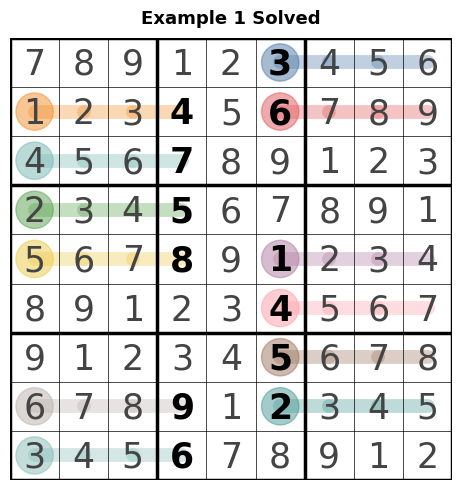

In [13]:
# Example 1 Visualization
fig, ax = plt.subplots(figsize=(5, 5))
draw_thermo_grid(ax, thermo_sudoku_1, thermo_info_1, solution_1, 'Example 1 Solved')
plt.tight_layout()
plt.show()

----------
## Thermo Example Test 2

<table style="width:60%">
  <tr>
    <td>Example 2 Problem</td>
    <td>Example 2 Reference Solution</td>
  </tr>
  <tr>
    <th><img src="./thermo_sudoku_examples/251124-ThermoSudoku-CompletelyUnexpectedThermo.jpg" alt="example2"></th>
    <th><img src="./thermo_sudoku_examples/251124-ThermoSudoku-CompletelyUnexpectedThermo-soln.jpg" alt="example2_soln"></th>
  </tr>
</table>

In [14]:
thermo_sudoku_2 = [
                    [0,0,0, 0,0,0, 0,0,0],
                    [0,0,0, 0,0,0, 1,0,0],
                    [0,0,2, 0,0,0, 5,0,0],

                    [0,0,0, 0,3,0, 0,0,1],
                    [0,0,0, 4,0,6, 0,0,0],
                    [9,0,0, 0,7,0, 0,0,0],

                    [0,0,5, 0,0,0, 8,0,0],
                    [0,0,9, 0,0,0, 0,0,0],
                    [0,0,0, 0,0,0, 0,0,0],
                ]

thermo_info_2 = [
                [(2,2),(1,3),(2,4),(1,5),(2,6),(1,7)],    # row 1-2
                [(4,3),(3,4),(2,5)],                      # row 2-4
                [(5,7),(4,7),(3,7)],                      # row 3-5
                [(5,3),(6,3),(7,3)],                      # row 5-7
                [(6,7),(7,6),(8,5)],                      # row 6-8
                [(2,8),(3,9),(4,8),(5,9),(6,8),(7,9)],    # row 2-7
                [(8,2),(7,1),(6,2),(5,1),(4,2),(3,1)],    # row 3-8
                [(8,8),(9,7),(8,6),(9,5),(8,4),(9,3)],    # row 8-9
                ]

solution_2 = solve_sudoku(input_sudoku=thermo_sudoku_2, type="thermo", thermometer_list=thermo_info_2)

Solution Status = Optimal


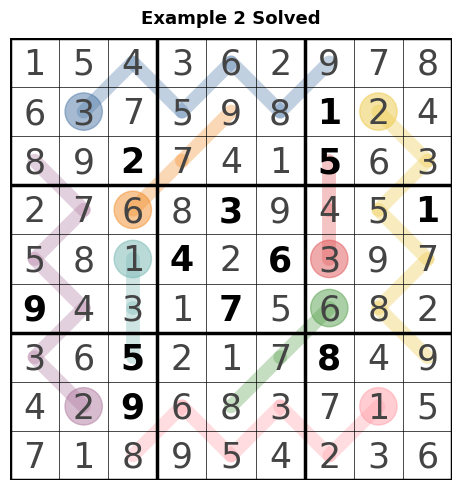

In [15]:
# Example 2 Visualization
fig, ax = plt.subplots(figsize=(5, 5))
draw_thermo_grid(ax, thermo_sudoku_2, thermo_info_2, solution_2, 'Example 2 Solved')
plt.tight_layout()
plt.show()

----------
## Thermo Example Test 3

<table style="width:60%">
  <tr>
    <td>Example 3 Problem</td>
    <td>Example 3 Reference Solution</td>
  </tr>
  <tr>
    <th><img src="./thermo_sudoku_examples/250920-ThermoSudoku-Sorry.jpg" alt="example3"></th>
    <th><img src="./thermo_sudoku_examples/250920-ThermoSudoku-Sorry-soln.jpg" alt="example3_soln"></th>
  </tr>
</table>

In [16]:
thermo_sudoku_3 = [
                    [1,0,0, 2,0,0, 4,0,0],
                    [0,0,0, 0,0,0, 0,0,0],
                    [0,0,0, 0,0,0, 0,0,0],

                    [0,0,0, 0,0,0, 0,0,0],
                    [0,0,0, 0,4,0, 0,0,0],
                    [0,0,0, 0,0,0, 0,0,0],

                    [0,0,0, 0,0,0, 0,0,0],
                    [0,0,0, 0,0,0, 0,0,0],
                    [0,0,5, 0,0,6, 0,0,7],
                ]

thermo_info_3 = [
                [(2,3),(2,2),(3,2),(3,3),(3,4),(4,4),(4,3)],        # s
                [(4,8),(4,7),(4,6),(3,6),(2,6),(2,7),(2,8),(3,8)],    # o
                [(6,1),(7,1),(8,1)],                        # r1 - down
                [(6,1),(7,1),(6,2),(6,3)],                    # r1 - up
                [(6,4),(7,4),(8,4)],                        # r2 - down
                [(6,4),(7,4),(6,5),(6,6)],                    # r2 - up
                [(8,8),(7,8),(6,7)],                        # y - left
                [(8,8),(7,8),(6,9)],                        # y - right
                ]

solution_3 = solve_sudoku(input_sudoku=thermo_sudoku_3, type="thermo", thermometer_list=thermo_info_3)

Solution Status = Optimal


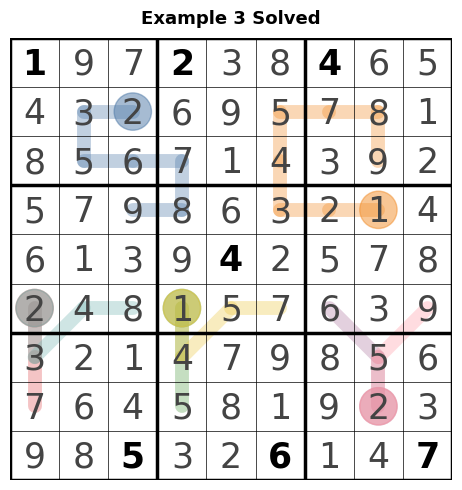

In [17]:
# Example 3 Visualization
fig, ax = plt.subplots(figsize=(5, 5))
draw_thermo_grid(ax, thermo_sudoku_3, thermo_info_3, solution_3, 'Example 3 Solved')
plt.tight_layout()
plt.show()